# Discovery of the Higgs Boson

**Final Project — Probability & Statistics for Data Analysis**

In 2012 the ATLAS and CMS experiments at the LHC announced a new particle
consistent with the Standard Model Higgs boson. In this project you reproduce
the logic of that discovery on real CMS four-lepton data, using exactly the
tools of this course: a classifier as a likelihood-ratio approximation
(Neyman–Pearson), a **generalized likelihood-ratio test** with a nuisance
parameter, toy-based p-values, and a power calculation.

**The arc.**

1. Frame discovery as a hypothesis test of background-only vs. background+signal.
2. Build a one-dimensional test statistic $h(x)$ from a classifier — and watch a
   *linear* one fail, for a reason you can prove.
3. Fix it (quadratic features, then a small neural net) and understand *why*.
4. Run the discovery test: a binned-Poisson GLRT mass fit with a **floating
   background normalization**, so a mis-modeled simulation cannot fake a signal.
5. Measure the signal strength $\hat\mu$ and find we have **evidence, not
   discovery** — then compute how much data a discovery would take.
6. Enter the class **leaderboard**: whose classifier extracts the most expected
   significance? The answer reveals why AUC is *not* the physics metric — and
   points at the next course.

> **Reproducibility.** Use the seed already set below. All heavy lifting lives in
> the tested modules `util.py` and `higgs_analysis.py` beside this notebook, so
> every cell here is short and readable.


## 0. Setup — run this cell first

If you opened this notebook standalone (e.g. from the Colab badge), the helper
modules and data files are not in your session. This cell fetches them from the
project repository. Run locally from a full checkout and it is a no-op.


In [1]:
# Colab bootstrap: fetch helper modules and data if they aren't already here.
import os, urllib.request

REPO = "https://raw.githubusercontent.com/codey-m/prob_stats/main/final_project"
NEEDED = [
    "util.py", "higgs_analysis.py",
    "data/MC/higgs2012.csv", "data/MC/zzto4mu2012.csv",
    "data/MC/zzto2mu2e2012.csv", "data/MC/zzto4e2012.csv",
    "data/data/clean_data_2012.csv",
]
for rel in NEEDED:
    if not os.path.exists(rel):
        folder = os.path.dirname(rel)
        if folder:
            os.makedirs(folder, exist_ok=True)
        urllib.request.urlretrieve(f"{REPO}/{rel}", rel)
        print(f"downloaded {rel}")
print("environment ready")


environment ready


In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.exceptions import ConvergenceWarning

import util
import higgs_analysis as H

# The small neural net is trained briefly on purpose (as in the original
# project); silence the expected "did not converge" notice.
warnings.filterwarnings("ignore", category=ConvergenceWarning)

SEED = 6372
np.random.seed(SEED)
plt.rcParams["figure.figsize"] = (7, 4)


## 1. The data and the simulation

We have two ingredients:

- **Experimental data**: ~495 real CMS events that survived the H→ZZ→4ℓ
  selection (four leptons, i.e. electrons/muons). Each event is described by the
  four-momenta $(E, p_x, p_y, p_z)$ of its four leptons, plus reconstructed
  masses.
- **Monte-Carlo simulation (MC)**: labeled events for the **Higgs signal** and
  the three **irreducible ZZ→4ℓ backgrounds** (`zz4mu`, `zz2mu2e`, `zz4e`). The
  reducible backgrounds (Drell–Yan, $t\bar t$) are negligible in this final
  state after selection and are not included.

Each MC process carries a physical **weight** — the number of expected events one
simulated row represents — from luminosity × cross-section / generated-count.
Summing weights gives the expected yield.


In [3]:
st = H.prepare(seed=0)
data = st["data"]
weights = util.compute_weights()

print(f"experimental events: {len(data)}")
print("MC process yields (expected events at this luminosity):")
for name, p, w in zip(util.PROCESS_NAMES, st["processes"], weights):
    print(f"  {name:9s}: {len(p):6d} rows  ->  yield {w*len(p):8.2f}")
tot_bkg = sum(w*len(p) for w, p in zip(weights[1:], st["processes"][1:]))
print(f"\ntotal expected background: {tot_bkg:.1f}")
print(f"total expected signal:     {weights[0]*len(st['processes'][0]):.1f}")
print(f"observed:                  {len(data)}   (data/prediction = "
      f"{len(data)/(tot_bkg+weights[0]*len(st['processes'][0])):.3f})")


experimental events: 495
MC process yields (expected events at this luminosity):
  higgs    :   9348 rows  ->  yield     9.38
  zz4mu    :  41106 rows  ->  yield   135.91
  zz2mu2e  :  26537 rows  ->  yield   204.39
  zz4e     :  21476 rows  ->  yield    71.00

total expected background: 411.3
total expected signal:     9.4
observed:                  495   (data/prediction = 1.177)


**Note the signal is tiny:** ~9 expected Higgs events on top of ~411
background. Discovery is a needle-in-haystack counting problem. Note too that the
data slightly *exceeds* the total prediction — the simulation normalization is
not perfect, a fact we will handle head-on in Section 4.


## 2. Weighting for the Neyman–Pearson connection

The most powerful test of background $P_0$ vs. signal $Q$ uses the
log-likelihood ratio $h^*(x) = \log\!\big(Q(x)/P_0(x)\big)$ (Neyman–Pearson).
We don't know $P_0, Q$ in closed form — only samples — but a classifier trained
with cross-entropy has log-odds that converge to $h^*$ **plus** a constant
$\log(\nu_1/\nu_0)$ set by the class proportions. Choosing **equal total signal
and background weight** ($\nu_0=\nu_1$) makes that constant zero, so the trained
log-odds *is* $\hat h \approx h^*$.

The provided `compute_weights()` returns honest **physical** weights. For
training we rebalance to equal class totals with `class_balanced_weights` — and
this is a real fix: the original project code set the Higgs weight to the *sum*
of the per-event background weights, giving ~137× too much signal weight and a
classifier that called almost everything signal.


In [4]:
full = st["train"]
sig = (full["_proc"] == 0).values
bal = util.class_balanced_weights(sig, full["_w"].values)
print(f"total signal weight     : {bal[sig].sum():.1f}")
print(f"total background weight  : {bal[~sig].sum():.1f}")
print(f"ratio (should be 1.000)  : {bal[sig].sum()/bal[~sig].sum():.3f}")


total signal weight     : 34462.5
total background weight  : 34462.5
ratio (should be 1.000)  : 1.000


## 3. A test statistic $h(x)$ — and why a linear model must fail

We deliberately hand the classifier only the **raw four-momenta** of the four
leptons — 24 numbers — and **withhold** the reconstructed masses. We want the
model to find the structure itself.

Start with logistic regression (a linear model, the course's workhorse).


linear logistic regression, weighted AUC = 0.632


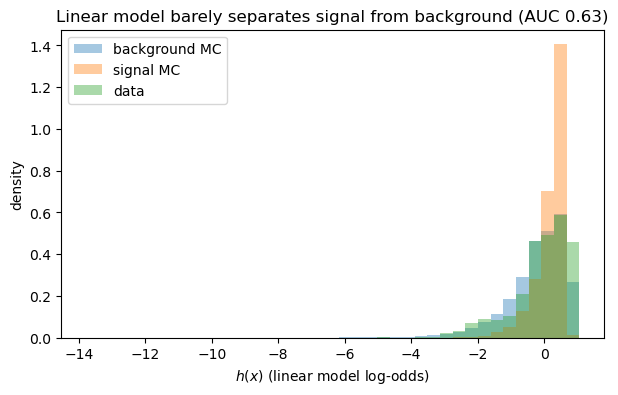

In [5]:
lin, featfn = H.make_classifier("linear", st["train"])
auc_lin = H.auc(lin, featfn, st["holdout"])
print(f"linear logistic regression, weighted AUC = {auc_lin:.3f}")

# distributions of h(x) for signal MC, background MC, and real data
h_sig  = H.score(lin, featfn, st["processes"][0])
h_bkg  = np.concatenate([H.score(lin, featfn, p) for p in st["processes"][1:]])
h_data = H.score(lin, featfn, data)
bins = np.linspace(min(h_bkg.min(), h_data.min()), max(h_sig.max(), h_data.max()), 40)
plt.hist(h_bkg,  bins=bins, density=True, alpha=0.4, label="background MC")
plt.hist(h_sig,  bins=bins, density=True, alpha=0.4, label="signal MC")
plt.hist(h_data, bins=bins, density=True, alpha=0.4, label="data")
plt.xlabel(r"$h(x)$ (linear model log-odds)"); plt.ylabel("density"); plt.legend()
plt.title(f"Linear model barely separates signal from background (AUC {auc_lin:.2f})")
plt.show()


AUC ≈ 0.63 — barely better than a coin flip. Is the Higgs simply not
separable from ZZ? No. The discriminating variable is the **four-lepton
invariant mass**, and there is a precise reason a *linear* model cannot see it:

$$ m^2 = \Big(\textstyle\sum_i E_i\Big)^2 - \Big(\sum_i p_{x,i}\Big)^2
        - \Big(\sum_i p_{y,i}\Big)^2 - \Big(\sum_i p_{z,i}\Big)^2 $$

The mass is **exactly a quadratic form** in the raw inputs. A linear function of
the inputs cannot represent it. Let's confirm the identity numerically.


In [6]:
d = data
E  = d[["E1","E2","E3","E4"]].values.sum(1)
px = d[["px1","px2","px3","px4"]].values.sum(1)
py = d[["py1","py2","py3","py4"]].values.sum(1)
pz = d[["pz1","pz2","pz3","pz4"]].values.sum(1)
m_reconstructed = np.sqrt(np.maximum(E**2 - px**2 - py**2 - pz**2, 0))
print(f"max |reconstructed mass - provided mass| = "
      f"{np.abs(m_reconstructed - d['mass'].values).max():.2e} GeV")
print("=> the target is a quadratic form in the inputs; a linear model cannot represent it.")


max |reconstructed mass - provided mass| = 5.61e-07 GeV
=> the target is a quadratic form in the inputs; a linear model cannot represent it.


So we give the model the capacity to form products of inputs. Two ways:

- **Quadratic feature expansion** on the raw inputs — represents $m^2$ *exactly*,
  and stays within linear-model machinery (regression, Unit 1).
- **A small neural network** (three hidden layers) — *approximates* $m^2$ from
  the raw inputs, learning the physicist's feature on its own.


In [7]:
quad, _ = H.make_classifier("quadratic", st["train"])
mlp,  _ = H.make_classifier("mlp", st["train"])
print("weighted AUC on the held-out MC (mass-blind raw inputs):")
print(f"  linear                       {H.auc(lin,  featfn, st['holdout']):.3f}")
print(f"  quadratic feature expansion  {H.auc(quad, featfn, st['holdout']):.3f}")
print(f"  3-layer neural net           {H.auc(mlp,  featfn, st['holdout']):.3f}")


weighted AUC on the held-out MC (mass-blind raw inputs):
  linear                       0.632
  quadratic feature expansion  0.906
  3-layer neural net           0.955


From 0.63 to ~0.91 (quadratic) and ~0.96 (neural net) — the same raw
inputs, now with the capacity to build the mass. The neural net rediscovered,
from four-momenta alone, the variable physicists spent years learning to
compute. That is the headline result of Baldi, Sadowski & Whiteson (2014).


## 4. The discovery test: a mass fit with a floating background

A classifier that separates simulated signal from simulated background is **not**
yet evidence for a particle. The simulation is imperfectly normalized (Section 1:
data/prediction ≈ 1.15). If we simply compared data to simulation, a *two-sample
test would reject the null because the normalization is wrong*, not because a
Higgs exists — a false-discovery trap.

The fix is the course's **generalized likelihood-ratio test**. Bin the events in
mass. Model the expected count in bin $i$ as

$$ \lambda_i = \mu\, S_i + \kappa\, B_i $$

- $S_i, B_i$: signal and background template yields from MC,
- $\mu$: **signal strength** ($\mu=0$ = no Higgs, $\mu=1$ = Standard Model rate),
- $\kappa$: a **free background normalization** (a nuisance parameter).

Letting $\kappa$ float means an overall mis-normalization is *absorbed*, not
mistaken for signal — only a localized bump with the Higgs mass shape can drive
$\mu>0$. We test $H_0:\mu=0$ with $q = 2\log\frac{\max_{\mu,\kappa}L}{\max_\kappa
L|_{\mu=0}}$.


mu_hat   (signal strength)     = 1.103
kappa_hat(background scale)     = 1.298
test statistic q               = 5.247
asymptotic significance sqrt(q) = 2.29 sigma


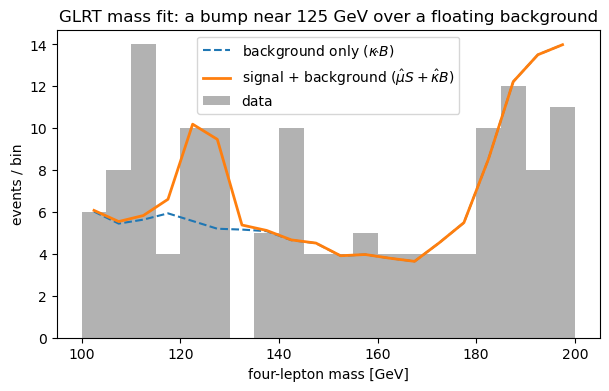

In [8]:
S, B, obs = H._templates(st)          # mass-only templates and observed counts
g = H.glrt(S, B, obs)
print(f"mu_hat   (signal strength)     = {g['mu_hat']:.3f}")
print(f"kappa_hat(background scale)     = {g['kappa_hat']:.3f}")
print(f"test statistic q               = {g['q']:.3f}")
print(f"asymptotic significance sqrt(q) = {g['Z_asymptotic']:.2f} sigma")

edges = np.linspace(H.MASS_LO, H.MASS_HI, H.N_BINS + 1)
ctr = 0.5*(edges[:-1] + edges[1:])
plt.bar(ctr, obs, width=np.diff(edges), alpha=0.3, label="data", color="k")
plt.plot(ctr, g['kappa_hat']*B, "--", label=r"background only ($\kappa\hat{}\,B$)")
plt.plot(ctr, g['mu_hat']*S + g['kappa_hat']*B, "-", lw=2,
         label=r"signal + background ($\hat\mu S+\hat\kappa B$)")
plt.xlabel("four-lepton mass [GeV]"); plt.ylabel("events / bin"); plt.legend()
plt.title("GLRT mass fit: a bump near 125 GeV over a floating background")
plt.show()


The asymptotic $\sqrt{q}$ is only an approximation (and $\mu=0$ sits on the
boundary $\mu\ge0$). The honest p-value comes from **toys**: simulate many
background-only pseudo-datasets, refit each, and see how often $q$ reaches the
observed value. A correctly-sized test also has a **uniform** p-value
distribution under the null — a goodness-of-fit check worth making.


In [9]:
tp = H.toy_pvalue(S, B, obs, n_toys=2000, seed=SEED)
print(f"toy-based p-value = {tp['p_value']:.4f}")
print(f"significance      = {tp['Z_toy']:.2f} sigma  (one-sided)")


toy-based p-value = 0.0130
significance      = 2.23 sigma  (one-sided)


## 5. Evidence, not discovery

The fit returns $\hat\mu \approx 1.1$ — **the signal strength lands on the
Standard Model value $\mu=1$**, which is exactly what a real Higgs should give —
at a significance of about **2.2–2.3σ**. In particle physics the conventions are:

- **3σ** ("evidence"): $p \approx 1.3\times10^{-3}$,
- **5σ** ("discovery"): $p \approx 2.9\times10^{-7}$.

So this dataset gives *evidence-like* strength, short of discovery. That is not a
failure of method — it is a statement about **information**. Which raises the
scientific question: how much data would a discovery take?


## 6. Power: how much data for 5σ?

This is a **power calculation** (hypothesis testing, Unit 2). Hold the physics
fixed at $\mu=1$ and ask what expected significance we would obtain with $N\times$
the integrated luminosity — signal and background both scale by $N$, and the
expected (Asimov) significance grows roughly like $\sqrt N$.


 lumi       S       B  expected Z
   1x     8.1     8.3        2.47
   2x    16.1    16.6        3.49
   4x    32.2    33.2        4.93
   5x    40.3    41.5        5.52   <= 5 sigma
   6x    48.4    49.8        6.04   <= 5 sigma
  10x    80.6    83.0        7.80   <= 5 sigma
  20x   161.2   165.9       11.03   <= 5 sigma


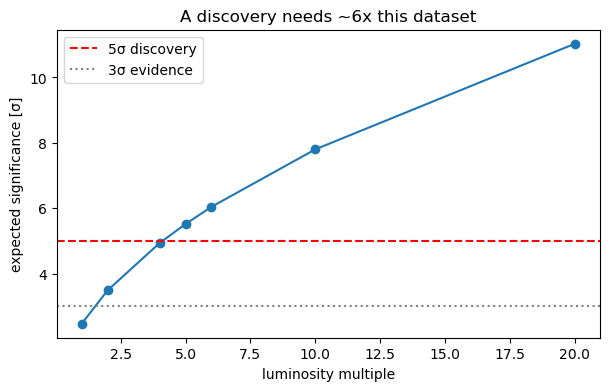

In [10]:
proj = H.luminosity_projection(st, factors=(1, 2, 4, 5, 6, 10, 20))
print(f"{'lumi':>5} {'S':>7} {'B':>7} {'expected Z':>11}")
for f, s, b, z in proj:
    print(f"{f:>4}x {s:7.1f} {b:7.1f} {z:11.2f}" + ("   <= 5 sigma" if z >= 5 else ""))

fac = [f for f,_,_,_ in proj]; zs = [z for *_,z in proj]
plt.plot(fac, zs, "o-"); plt.axhline(5, ls="--", color="r", label="5σ discovery")
plt.axhline(3, ls=":", color="gray", label="3σ evidence")
plt.xlabel("luminosity multiple"); plt.ylabel("expected significance [σ]"); plt.legend()
plt.title("A discovery needs ~6x this dataset"); plt.show()


**About 5× this dataset crosses 5σ** (between the 4× and 6× rows). And this is
exactly what history did: the LHC went on to collect far more than that 2012
four-lepton sample, and H→ZZ→4ℓ is now
a >5σ observation and a precision-measured channel. **The method was right; the
2012 four-lepton dataset was luminosity-limited.** You found the bump, you
measured $\hat\mu\approx1$, and you can say precisely what discovery costs — which
is why CMS and ATLAS combined channels and years to get there.


## 7. The leaderboard — and why AUC is not the physics metric

Your classifier plugs into this analysis as the score $h(x)$. The class
leaderboard ranks entries not by AUC but by the quantity that matters: the
**expected significance of the full analysis**, computed from **MC only** (never
the real 495 events — ranking on those would be model selection on the discovery
data). We use the score as a *second fit dimension* alongside mass (a 2D
mass×score GLRT), the way ATLAS and CMS actually do it — so a good score can only
add information, never discard it.

Three columns: **AUC** (raw separation), **expected Z** (the rank metric), and
**sideband retention** (the fraction of off-peak background an 80%-signal cut
would keep — a mass-sculpting diagnostic).


In [11]:
baseline = H.mass_only_expected_Z(st)
print(f"mass-only baseline (no classifier): expected Z = {baseline:.2f}\n")
print(f"{'entry':>26} {'AUC':>7} {'expected Z':>11} {'sideband ret.':>14}")
for kind, (mdl, fx) in {"linear": (lin, featfn),
                        "quadratic feature exp.": (quad, featfn),
                        "3-layer neural net": (mlp, featfn)}.items():
    r = H.leaderboard_row(mdl, fx, st)
    print(f"{kind:>26} {r['auc']:7.3f} {r['expected_Z']:11.2f} "
          f"{r['sideband_retention']:14.2f}")


mass-only baseline (no classifier): expected Z = 2.31

                     entry     AUC  expected Z  sideband ret.
                    linear   0.632        2.31           0.49


    quadratic feature exp.   0.906        2.66           0.11
        3-layer neural net   0.955        2.56           0.03


Read the table carefully — it contains the lesson:

- **Every classifier scores at least the mass-only baseline**, because a score
  used as a fit dimension can only add information. The *linear* model adds
  essentially nothing (its only real signal *is* mass, already in the fit).
- **The neural net has the highest AUC but does not top the ranking.** AUC
  measures raw separation; expected Z measures *new* information beyond mass.
  A classifier that mostly re-learned the mass is highly redundant with the axis
  we already fit.
- **Sideband retention collapses** as AUC climbs (≈0.49 → 0.11 → 0.03). A model
  that learned mass, used as a hard *cut*, would carve away exactly the off-peak
  events that pin $\kappa$ — destroying the background constraint. That is why we
  fit the score instead of cutting on it.

**The frontier — and the next course.** To beat this baseline substantially you
want separation that is **decorrelated from mass**: real kinematic information the
mass fit doesn't already have. Building classifiers that are powerful *and*
decorrelated (adversarial training, mass-decorrelated taggers, learned
categorization) is exactly where machine learning for the physical sciences goes
next.


## 8. Report your results

Enter these on the submission page. They come straight from the frozen pipeline
above.


In [12]:
results = {
    "mu_hat":            round(g["mu_hat"], 3),
    "kappa_hat":         round(g["kappa_hat"], 3),
    "glrt_q":            round(g["q"], 3),
    "toy_p_value":       round(tp["p_value"], 4),
    "significance_sigma":round(tp["Z_toy"], 2),
    "auc_linear":        round(H.auc(lin,  featfn, st["holdout"]), 3),
    "auc_quadratic":     round(H.auc(quad, featfn, st["holdout"]), 3),
    "auc_mlp":           round(H.auc(mlp,  featfn, st["holdout"]), 3),
    "leaderboard_expected_Z": round(H.leaderboard_row(mlp, featfn, st)["expected_Z"], 2),
    "lumi_factor_for_5sigma": next(f for f,_,_,z in
                                   H.luminosity_projection(st, factors=range(1,13)) if z >= 5),
}
for k, v in results.items():
    print(f"{k:28s} = {v}")


mu_hat                       = 1.103
kappa_hat                    = 1.298
glrt_q                       = 5.247
toy_p_value                  = 0.013
significance_sigma           = 2.23
auc_linear                   = 0.632
auc_quadratic                = 0.906
auc_mlp                      = 0.955
leaderboard_expected_Z       = 2.56
lumi_factor_for_5sigma       = 5
